## Agent 1

In [1]:
import os
from dotenv  import load_dotenv
load_dotenv()
# Read your API key from the environment variable or set it manually
api_key = os.getenv("GOOGLE_API_KEY")

In [3]:
# Create LLM class
from langchain_google_genai import ChatGoogleGenerativeAI

cal_agent = ChatGoogleGenerativeAI(
    model= "gemini-2.0-flash",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)
from typing import (
    Annotated,
    Sequence,
    TypedDict,
)
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    """The state of the agent."""
    messages: Annotated[Sequence[BaseMessage], add_messages]

from langchain_core.tools import tool

@tool
def add(first_int: int, second_int: int) -> int:
    "Add two integers."
    return first_int + second_int

@tool
def multiply(first_int: int, second_int: int) -> int:
    "Multiply two integers together."
    return first_int * second_int

@tool
def exponentiate(base: int, exponent: int) -> int:
    "Exponentiate the base to the exponent power."
    return base**exponent

cal_tools = [multiply, add, exponentiate]
cal_model = cal_agent.bind_tools(cal_tools)
print(cal_model.invoke(f"Take 3 to the fifth power and multiply that by the sum of twelve and three, then square the whole result"))
    

content='' additional_kwargs={'function_call': {'name': 'add', 'arguments': '{"second_int": 3.0, "first_int": 12.0}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []} id='run--fa309f76-ed54-4f28-8c6b-25e57fb1d800-0' tool_calls=[{'name': 'exponentiate', 'args': {'exponent': 5.0, 'base': 3.0}, 'id': '61e9a01b-b0d4-4e57-9cfe-8c29ffed145f', 'type': 'tool_call'}, {'name': 'add', 'args': {'second_int': 3.0, 'first_int': 12.0}, 'id': '5e499f24-e910-4de6-a1d1-0dca60325f7b', 'type': 'tool_call'}]


In [4]:
import json
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_core.runnables import RunnableConfig

# Define the node that calls the model
def call_model(
    state: AgentState,
):
    # this is similar to customizing the create_react_agent with 'prompt' parameter, but is more flexible
    system_prompt = SystemMessage(
        "You are a helpful AI assistant!"
    )
    response = cal_agent.invoke([system_prompt] + state["messages"])

    # We return a list, because this will get added to the existing list
    return {"messages": [response]}

In [5]:
import json
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_core.runnables import RunnableConfig

cal_tools_by_name = {tool.name: tool for tool in cal_tools}


# Define our tool node
def tool_node(state: AgentState):
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = cal_tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}


# Define the node that calls the model
def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # this is similar to customizing the create_react_agent with 'prompt' parameter, but is more flexible
    system_prompt = SystemMessage(
        "You are a helpful AI assistant, please respond to the users query to the best of your ability!"
    )
    response = cal_model.invoke([system_prompt] + state["messages"], config)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    
    last_message = messages[-1]
    # print("should_continue", state, "last_message", last_message)
    
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"

In [6]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow1 = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow1.add_node("agent", call_model)
workflow1.add_node("tools", tool_node)

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow1.set_entry_point("agent")

# We now add a conditional edge
workflow1.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
    # Finally we pass in a mapping.
    # The keys are strings, and the values are other nodes.
    # END is a special node marking that the graph should finish.
    # What will happen is we will call `should_continue`, and then the output of that
    # will be matched against the keys in this mapping.
    # Based on which one it matches, that node will then be called.
    {
        # If `tools`, then we call the tool node.
        "continue": "tools",
        # Otherwise we finish.
        "end": END,
    },
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow1.add_edge("tools", "agent")


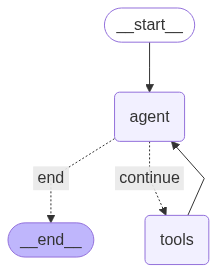

In [16]:

# Now we can compile and visualize our graph
graph1 = workflow1.compile()

from IPython.display import Image, display

try:
    display(Image(graph1.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [19]:
# Helper function for formatting the stream nicely
def print_stream(stream):
    for s in stream:
        # print(s)
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {"messages": [("user", "Take 3 to the fifth power and multiply that by the sum of twelve and three, then square the whole result")]}
print_stream(graph1.stream(inputs, stream_mode="values"))

================================ Human Message =================================

Take 3 to the fifth power and multiply that by the sum of twelve and three, then square the whole result
================================== Ai Message ==================================
Tool Calls:
  exponentiate (b695cb8d-f0f4-4cca-8050-c784b6d4f65f)
 Call ID: b695cb8d-f0f4-4cca-8050-c784b6d4f65f
  Args:
    exponent: 5.0
    base: 3.0
  add (4d951a6d-d390-41e9-8aa8-6bfeb3b2d919)
 Call ID: 4d951a6d-d390-41e9-8aa8-6bfeb3b2d919
  Args:
    second_int: 3.0
    first_int: 12.0
================================= Tool Message =================================
Name: add

15
================================== Ai Message ==================================

First, we need to find 3 to the fifth power, which is 243. Then, we need to add 12 and 3, which is 15. Now, we multiply 243 by 15, which is 3645. Finally, we square 3645, which is 13286025.


In [18]:
# Helper function for formatting the stream nicely
def print_stream(stream):
    for s in stream:
        # print(s)
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {"messages": [("user", "weather in pune")]}
print_stream(graph1.stream(inputs, stream_mode="values"))

================================ Human Message =================================

weather in pune
================================== Ai Message ==================================

I am sorry, I cannot fulfill this request. The available tools lack the desired functionality.


# Agent 2

In [26]:
# Create LLM class
from langchain_google_genai import ChatGoogleGenerativeAI

weather_agent = ChatGoogleGenerativeAI(
    model= "gemini-2.0-flash",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key,
)

@tool
def get_weather(country: str):
    """Call to get the weather from a specific country."""
    # This is a placeholder for the actual implementation
    # Don't let the LLM know this though 😊
    if any([city in country.lower() for city in ["in", "India"]]):
        return "It's sunny in India, but you better look out if you're a Gemini 😈."
    else:
        return f"I am not sure what the weather is in {country}"

weather_tools = [get_weather]

weather_model = weather_agent.bind_tools(weather_tools)
print(weather_model.invoke(f"what is weather in india, pune"))
    

content='I cannot access weather for a specific city. I can only access weather for an entire country. Would you like to know the weather in India?' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []} id='run--ab5a7fd7-f6e0-4a0e-a4ab-67d94db8908c-0'


In [27]:
import json
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_core.runnables import RunnableConfig

weather_tools_by_name = {tool.name: tool for tool in weather_tools}


# Define our tool node
def tool_node(state: AgentState):
    outputs = []
    for tool_call in state["messages"][-1].tool_calls:
        tool_result = weather_tools_by_name[tool_call["name"]].invoke(tool_call["args"])
        outputs.append(
            ToolMessage(
                content=json.dumps(tool_result),
                name=tool_call["name"],
                tool_call_id=tool_call["id"],
            )
        )
    return {"messages": outputs}

# Define the node that calls the model
def call_model(
    state: AgentState,
    config: RunnableConfig,
):
    # this is similar to customizing the create_react_agent with 'prompt' parameter, but is more flexible
    system_prompt = SystemMessage(
        "You are a helpful AI assistant, please respond to the users query to the best of your ability!"
    )
    response = weather_model.invoke([system_prompt] + state["messages"], config)
    # We return a list, because this will get added to the existing list
    return {"messages": [response]}


# Define the conditional edge that determines whether to continue or not
def should_continue(state: AgentState):
    messages = state["messages"]
    
    last_message = messages[-1]
    # print("should_continue", state, "last_message", last_message)
    
    # If there is no function call, then we finish
    if not last_message.tool_calls:
        return "end"
    # Otherwise if there is, we continue
    else:
        return "continue"


In [28]:
from langgraph.graph import StateGraph, END

# Define a new graph
workflow2 = StateGraph(AgentState)

# Define the two nodes we will cycle between
workflow2.add_node("agent", call_model)
workflow2.add_node("tools", tool_node)

# Set the entrypoint as `agent`
# This means that this node is the first one called
workflow2.set_entry_point("agent")

# We now add a conditional edge
workflow2.add_conditional_edges(
    # First, we define the start node. We use `agent`.
    # This means these are the edges taken after the `agent` node is called.
    "agent",
    # Next, we pass in the function that will determine which node is called next.
    should_continue,
    # Finally we pass in a mapping.
    # The keys are strings, and the values are other nodes.
    # END is a special node marking that the graph should finish.
    # What will happen is we will call `should_continue`, and then the output of that
    # will be matched against the keys in this mapping.
    # Based on which one it matches, that node will then be called.
    {
        # If `tools`, then we call the tool node.
        "continue": "tools",
        # Otherwise we finish.
        "end": END,
    },
)

# We now add a normal edge from `tools` to `agent`.
# This means that after `tools` is called, `agent` node is called next.
workflow2.add_edge("tools", "agent")


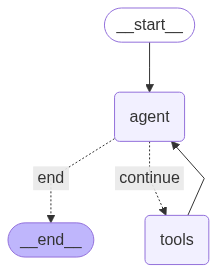

In [29]:

# Now we can compile and visualize our graph
graph2 = workflow2.compile()

from IPython.display import Image, display

try:
    display(Image(graph2.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass


In [30]:
# Helper function for formatting the stream nicely
def print_stream(stream):
    for s in stream:
        # print(s)
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {"messages": [("user", "weather in india")]}
print_stream(graph2.stream(inputs, stream_mode="values"))

================================ Human Message =================================

weather in india
================================== Ai Message ==================================
Tool Calls:
  get_weather (76535d3a-14ae-4f4f-866c-9647341f09f8)
 Call ID: 76535d3a-14ae-4f4f-866c-9647341f09f8
  Args:
    country: india
================================= Tool Message =================================
Name: get_weather

"It's sunny in India, but you better look out if you're a Gemini \ud83d\ude08."
================================== Ai Message ==================================

It's sunny in India, but you better look out if you're a Gemini 😈.


In [36]:
# Helper function for formatting the stream nicely
def print_stream(stream):
    for s in stream:
        # print(s)
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()


inputs = {"messages": [("user", "hi how are u. what can u do for me")]}
print_stream(graph2.stream(inputs, stream_mode="values"))

================================ Human Message =================================

hi how are u. what can u do for me
================================== Ai Message ==================================

I am doing well, thank you for asking! I can get the weather from a specific country for you. Just let me know which country you're interested in.


# Agent Architectures

In [37]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model= "gemini-2.0-flash",
    temperature=1.0,
    max_retries=2,
    google_api_key=api_key)